
# Market Segmentation using Machine Learning

## End-to-End Practical Tutorial with Python

### Learning Objectives
By the end of this notebook, students will be able to:

- Understand the concept of market segmentation
- Perform exploratory data analysis (EDA)
- Preprocess customer datasets
- Apply clustering algorithms for segmentation
- Determine the optimal number of clusters
- Visualize customer groups
- Interpret business insights from segments
- Build a complete machine learning workflow for market segmentation

---

## What is Market Segmentation?

Market segmentation is the process of dividing customers into groups based on shared characteristics such as:

- Age
- Income
- Spending behavior
- Lifestyle
- Purchase frequency
- Geographic location

Organizations use market segmentation to:

- Improve marketing campaigns
- Personalize customer experiences
- Increase sales and customer retention
- Identify profitable customer groups

---

## Machine Learning for Market Segmentation

Unsupervised machine learning algorithms are commonly used for segmentation because customer labels are usually unavailable.

Common algorithms include:

1. K-Means Clustering
2. Hierarchical Clustering
3. DBSCAN
4. Gaussian Mixture Models

In this notebook, we mainly focus on:
- K-Means Clustering
- Hierarchical Clustering

---


In [1]:

# Import required libraries

import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Statistical libraries
from scipy.cluster.hierarchy import dendrogram, linkage

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print("Libraries imported successfully.")


Libraries imported successfully.



# Step 1 — Create a Sample Customer Dataset

In a real-world project, organizations collect customer data from:

- CRM systems
- Websites
- Mobile applications
- Loyalty programs
- Point-of-sale systems

For teaching purposes, we will generate a realistic synthetic dataset containing:

- Customer ID
- Age
- Annual Income
- Spending Score
- Online Shopping Frequency
- Family Size

The dataset simulates different customer behaviors.


In [2]:

# Create synthetic customer data

np.random.seed(42)

n_customers = 500

customer_id = np.arange(1, n_customers + 1)

age = np.random.randint(18, 70, n_customers)

income = np.random.normal(60000, 18000, n_customers).astype(int)

spending_score = np.random.randint(1, 100, n_customers)

online_frequency = np.random.randint(1, 30, n_customers)

family_size = np.random.randint(1, 7, n_customers)

# Create DataFrame
df = pd.DataFrame({
    'CustomerID': customer_id,
    'Age': age,
    'AnnualIncome': income,
    'SpendingScore': spending_score,
    'OnlineShoppingFrequency': online_frequency,
    'FamilySize': family_size
})

# Remove negative income values if any
df['AnnualIncome'] = df['AnnualIncome'].abs()

# Display first few rows
df.head()


,CustomerID,Age,AnnualIncome,SpendingScore,OnlineShoppingFrequency,FamilySize
0,1,56,98198,59,16,3
1,2,69,78584,39,22,5
2,3,46,32651,99,22,6
3,4,32,51283,54,28,6
4,5,60,82804,98,20,5


In [3]:

# Save dataset as CSV file

df.to_csv('market_segmentation_dataset.csv', index=False)

print("Dataset saved successfully as market_segmentation_dataset.csv")


Dataset saved successfully as market_segmentation_dataset.csv



# Step 2 — Exploratory Data Analysis (EDA)

EDA helps us understand:

- Data distribution
- Relationships between variables
- Potential outliers
- Customer behavior patterns

EDA is one of the most important stages in data science projects.


In [4]:

# Dataset dimensions

print("Dataset Shape:", df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

# Summary statistics
print("\nSummary Statistics:")
df.describe()


Dataset Shape: (500, 6)

Data Types:
CustomerID                 int32
Age                        int32
AnnualIncome               int32
SpendingScore              int32
OnlineShoppingFrequency    int32
FamilySize                 int32
dtype: object

Summary Statistics:


,CustomerID,Age,AnnualIncome,SpendingScore,OnlineShoppingFrequency,FamilySize
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,44.220000,59468.794000,50.964000,14.580000,3.568000
std,144.481833,15.036082,17887.756642,29.064001,8.310097,1.712086
min,1.000000,18.000000,1657.000000,1.000000,1.000000,1.000000
25%,125.750000,32.000000,47143.000000,25.000000,8.000000,2.000000
50%,250.500000,45.000000,59594.000000,50.500000,14.000000,4.000000
75%,375.250000,57.000000,71315.750000,77.000000,22.000000,5.000000
max,500.000000,69.000000,115419.000000,99.000000,29.000000,6.000000


In [5]:

# Check for missing values

df.isnull().sum()


CustomerID                 0
Age                        0
AnnualIncome               0
SpendingScore              0
OnlineShoppingFrequency    0
FamilySize                 0
dtype: int64


# Visualizing Feature Distributions

Histograms help us understand:

- Normal distributions
- Skewness
- Outliers
- Customer patterns


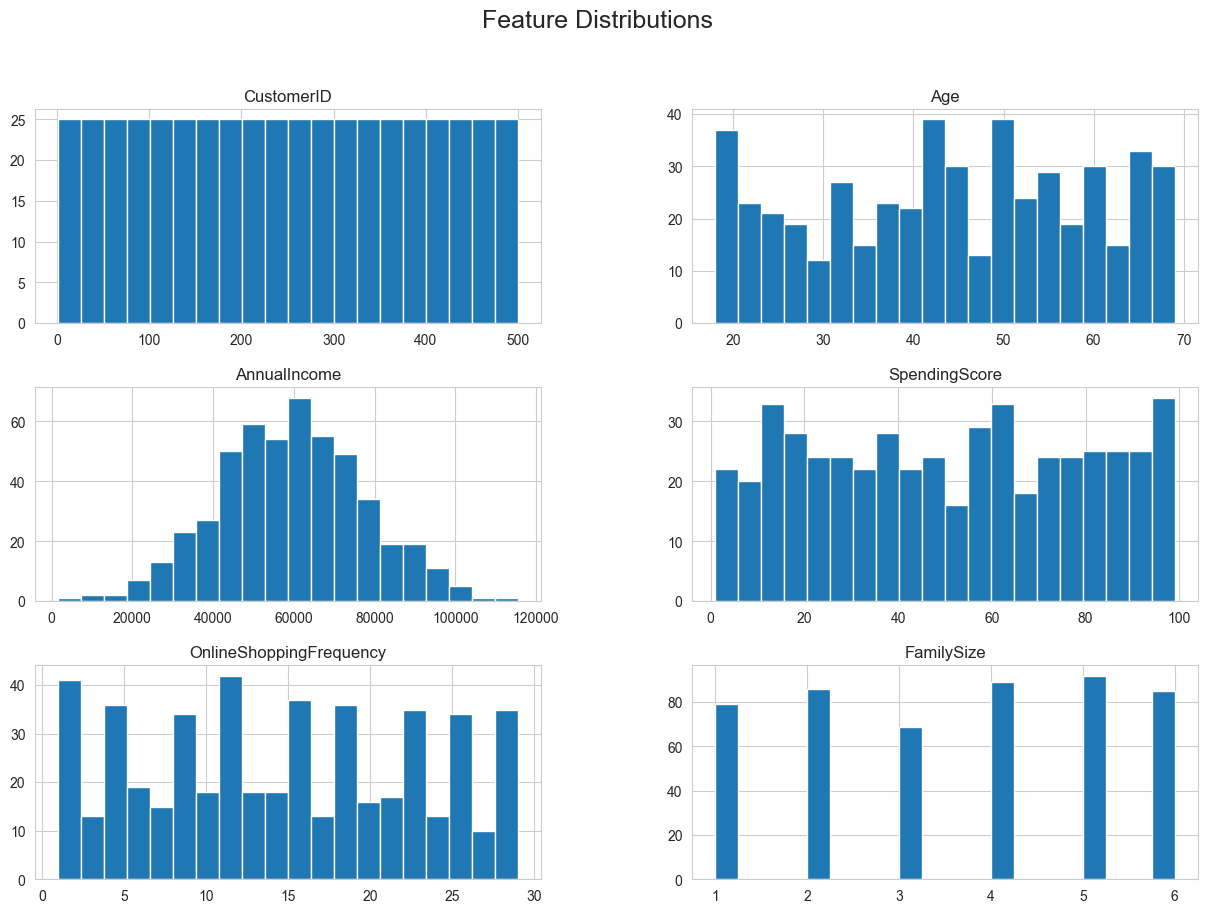

In [6]:

# Histograms

df.hist(bins=20, figsize=(15, 10))

plt.suptitle("Feature Distributions", fontsize=18)

plt.show()



# Pairplot Visualization

Pairplots help identify:

- Relationships between variables
- Cluster structures
- Correlations


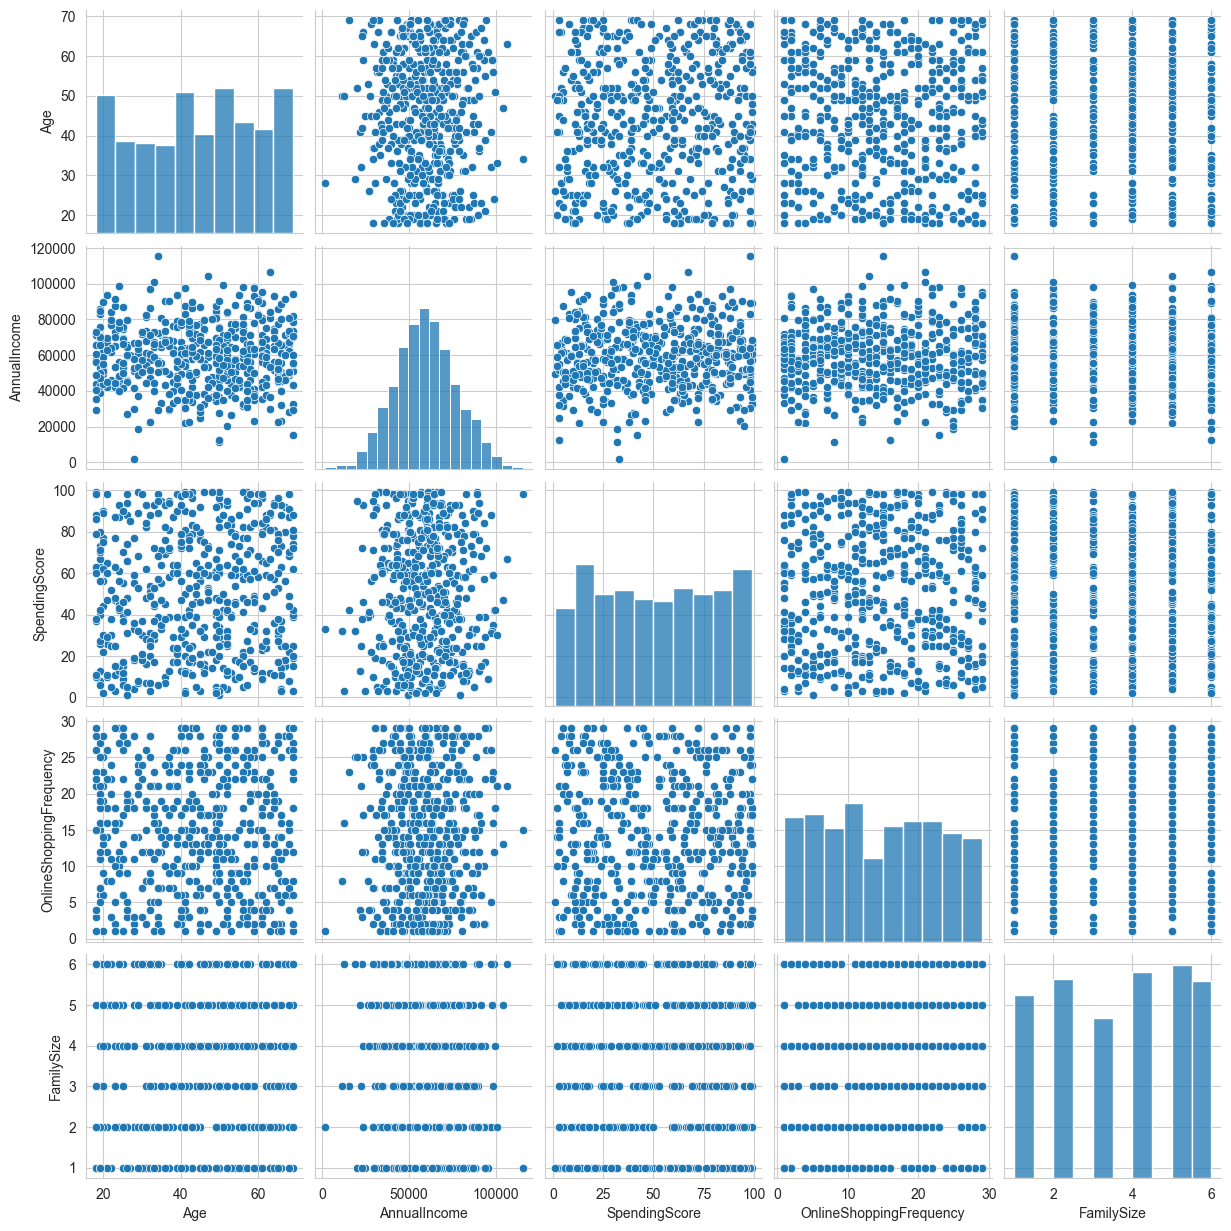

In [7]:

# Pairplot

sns.pairplot(df.drop(columns=['CustomerID']))

plt.show()



# Correlation Analysis

Correlation analysis helps determine whether variables are strongly related.


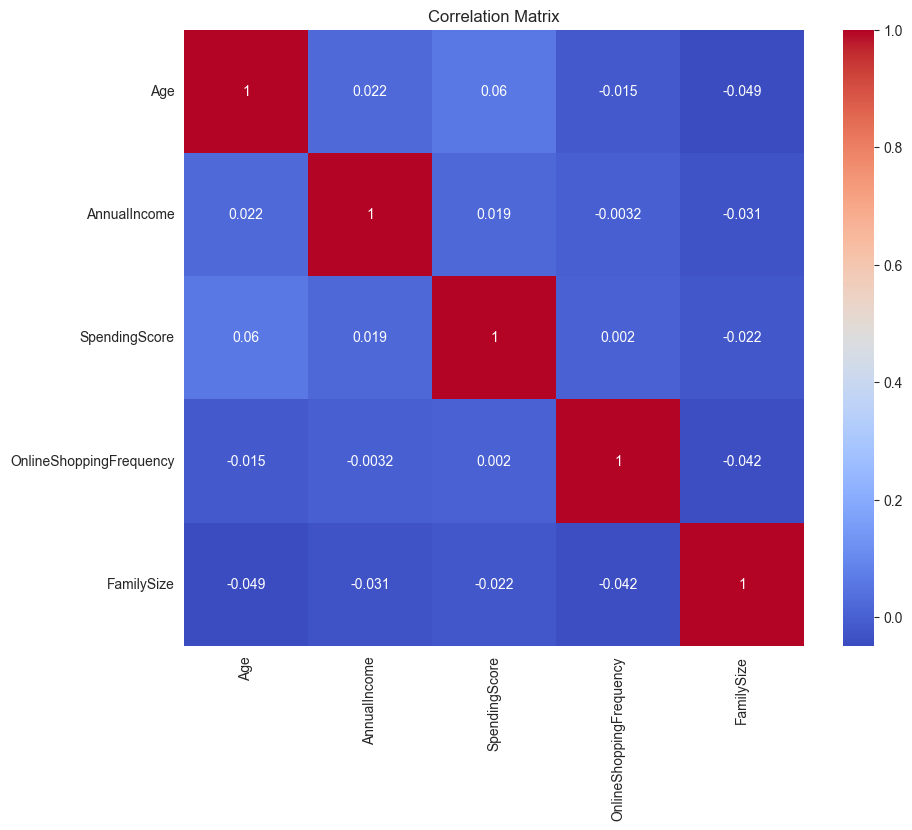

In [8]:

# Correlation matrix

corr = df.drop(columns=['CustomerID']).corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()



# Step 3 — Data Preprocessing

Machine learning algorithms are sensitive to feature scales.

For example:

- Income values may range in thousands
- Spending score may range from 1–100

Standardization ensures all features contribute equally.


In [9]:

# Select features

features = df.drop(columns=['CustomerID'])

# Standardization

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

print("Data standardized successfully.")


Data standardized successfully.



# Step 4 — Determine Optimal Number of Clusters

K-Means requires the number of clusters (K) as input.

We use:
1. Elbow Method
2. Silhouette Score

to identify the best number of clusters.


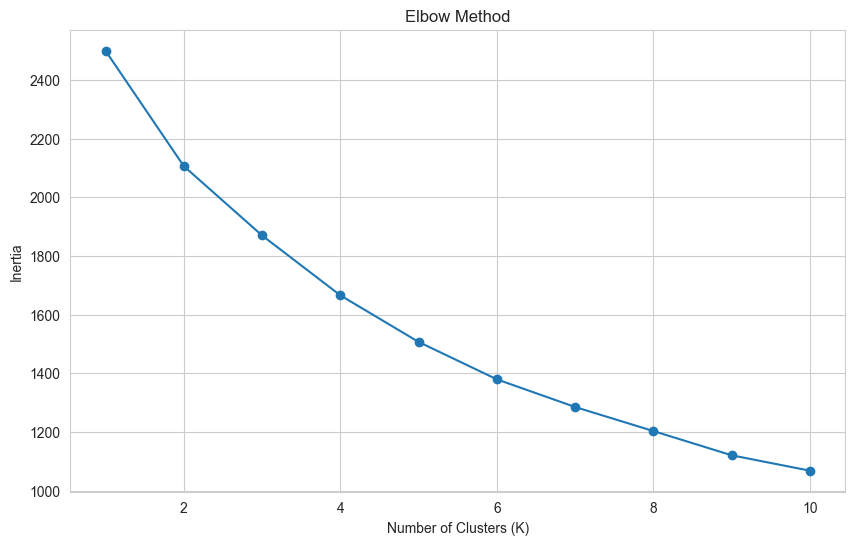

In [10]:

# Elbow Method

inertia_values = []

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia_values.append(kmeans.inertia_)

# Plot elbow curve

plt.plot(k_range, inertia_values, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()



# Silhouette Score Analysis

Silhouette score measures how well-separated clusters are.

Score range:
- Near +1 → Well separated
- Near 0 → Overlapping clusters
- Near -1 → Poor clustering


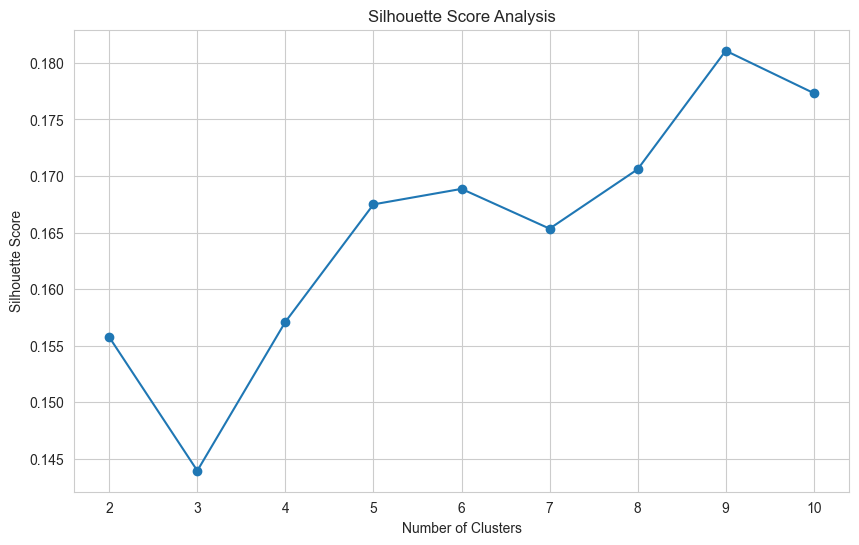

Best K based on silhouette score: 9


In [11]:

# Silhouette Scores

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    
    score = silhouette_score(scaled_features, labels)
    
    silhouette_scores.append(score)

# Plot scores

plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Analysis")

plt.show()

# Best score
best_k = np.argmax(silhouette_scores) + 2

print("Best K based on silhouette score:", best_k)



# Step 5 — Apply K-Means Clustering

Now we train the clustering model using the optimal number of clusters.


In [12]:

# Train K-Means model

kmeans = KMeans(n_clusters=best_k, random_state=42)

clusters = kmeans.fit_predict(scaled_features)

# Add cluster labels to dataframe

df['Cluster'] = clusters

# Display first few rows

df.head()


,CustomerID,Age,AnnualIncome,SpendingScore,OnlineShoppingFrequency,FamilySize,Cluster
0,1,56,98198,59,16,3,1
1,2,69,78584,39,22,5,1
2,3,46,32651,99,22,6,2
3,4,32,51283,54,28,6,7
4,5,60,82804,98,20,5,2



# Step 6 — Analyze Customer Segments

We now analyze the average characteristics of each customer segment.


In [13]:

# Cluster summary statistics

cluster_summary = df.groupby('Cluster').mean()

cluster_summary


,CustomerID,Age,AnnualIncome,SpendingScore,OnlineShoppingFrequency,FamilySize
Cluster,,,,,,
0,226.842105,28.929825,67236.017544,54.578947,7.771930,5.087719
1,247.921569,51.352941,81047.843137,34.196078,21.823529,2.803922
2,255.984848,55.818182,55207.181818,78.909091,12.333333,5.075758
3,309.760870,56.673913,55345.478261,21.673913,8.673913,4.978261
4,252.666667,39.816667,49743.850000,32.533333,6.533333,1.916667
5,247.181818,52.954545,43817.681818,52.954545,23.166667,2.909091
6,237.084746,30.881356,57194.220339,79.338983,18.169492,2.491525
7,246.807692,28.288462,58612.326923,23.961538,22.173077,4.903846
8,238.046512,55.209302,76280.000000,70.883721,8.720930,1.813953



# Boxplots by Cluster

These visualizations help compare customer groups.


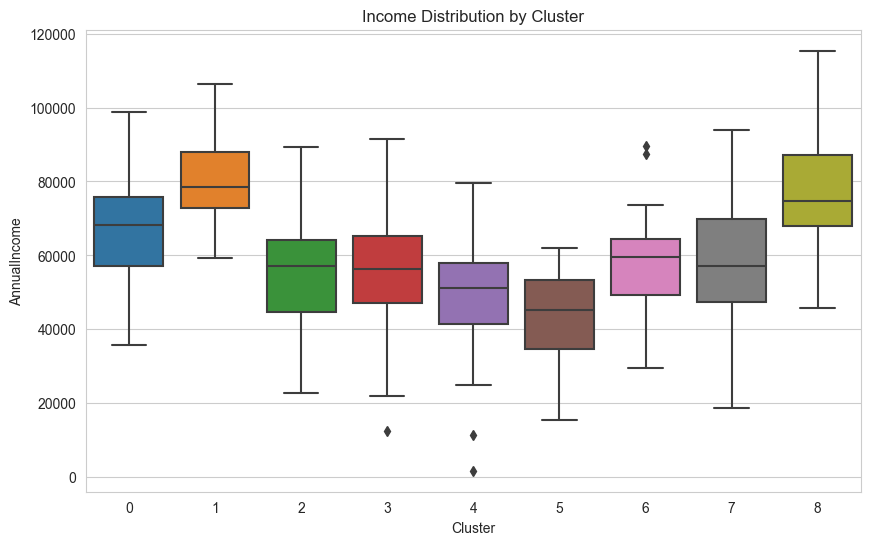

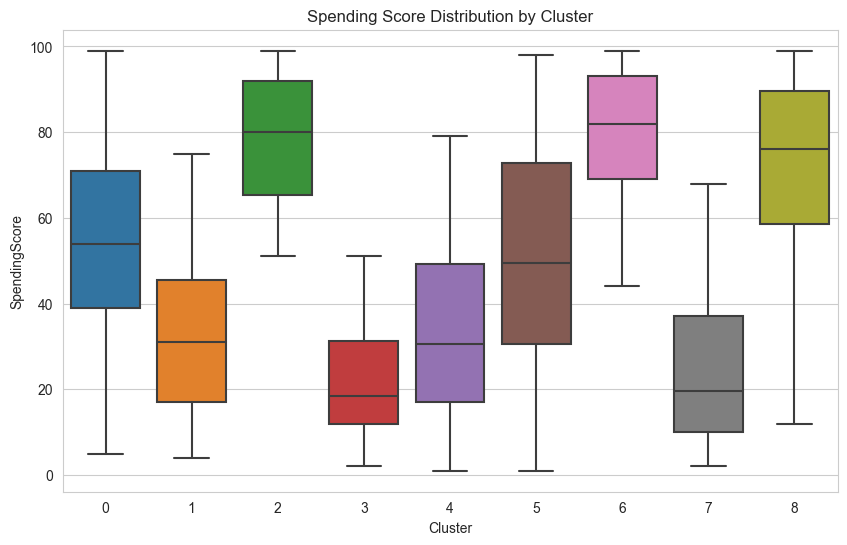

In [14]:

# Income by cluster

sns.boxplot(x='Cluster', y='AnnualIncome', data=df)

plt.title("Income Distribution by Cluster")

plt.show()

# Spending score by cluster

sns.boxplot(x='Cluster', y='SpendingScore', data=df)

plt.title("Spending Score Distribution by Cluster")

plt.show()



# Step 7 — PCA Visualization

Principal Component Analysis (PCA) reduces high-dimensional data into 2D for visualization.

This helps us visually inspect cluster separation.


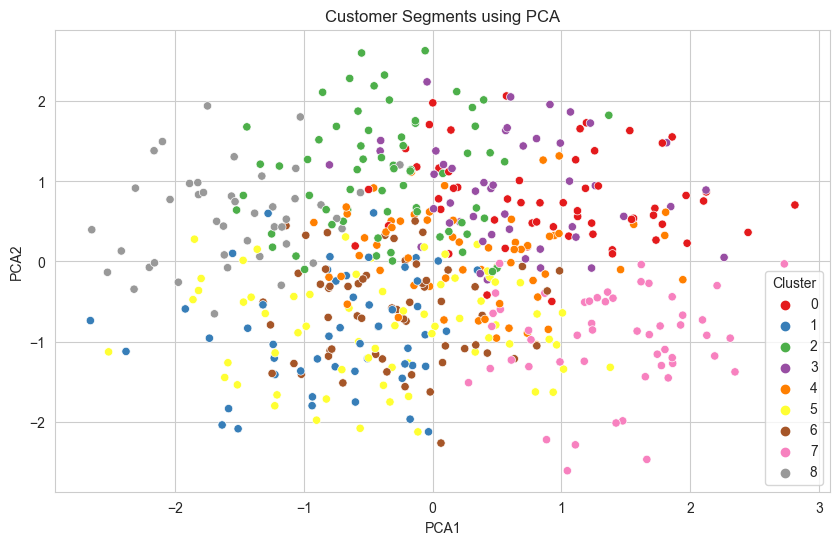

In [15]:

# PCA transformation

pca = PCA(n_components=2)

pca_components = pca.fit_transform(scaled_features)

# Create PCA DataFrame

pca_df = pd.DataFrame({
    'PCA1': pca_components[:, 0],
    'PCA2': pca_components[:, 1],
    'Cluster': clusters
})

# Scatter plot

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set1',
    data=pca_df
)

plt.title("Customer Segments using PCA")

plt.show()



# Step 8 — Hierarchical Clustering

Hierarchical clustering creates a tree-like structure called a dendrogram.

Advantages:
- No need to predefine K initially
- Easy visualization
- Useful for smaller datasets


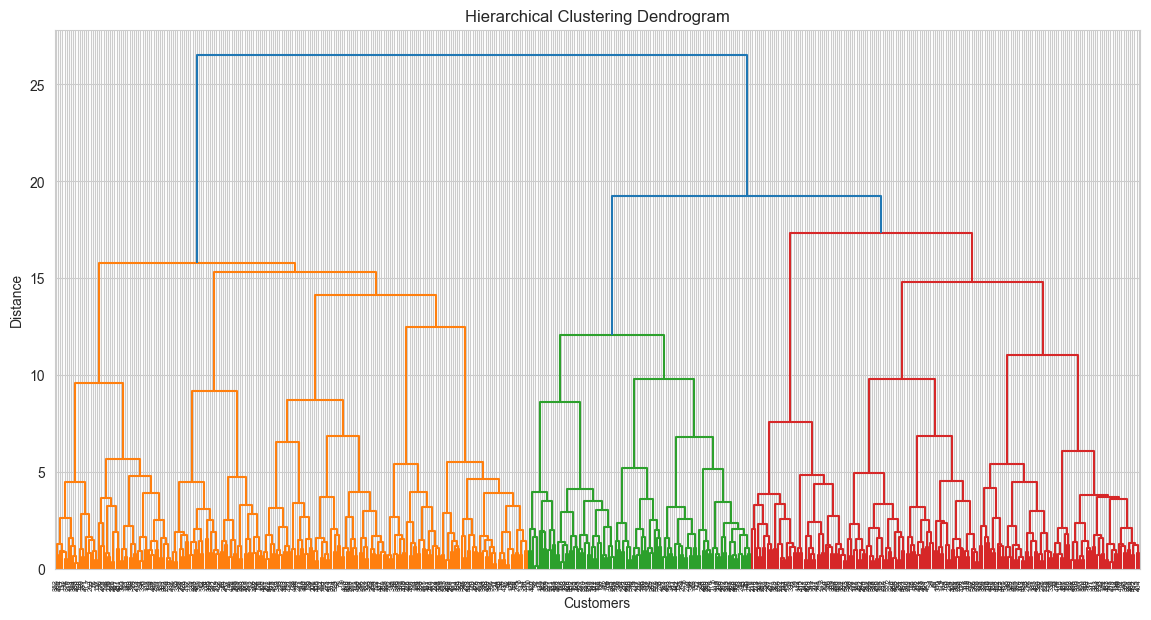

In [16]:

# Generate linkage matrix

linked = linkage(scaled_features, method='ward')

# Plot dendrogram

plt.figure(figsize=(14, 7))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Customers")

plt.ylabel("Distance")

plt.show()


In [17]:

# Agglomerative clustering

agglo = AgglomerativeClustering(n_clusters=best_k)

agglo_labels = agglo.fit_predict(scaled_features)

# Add labels

df['AgglomerativeCluster'] = agglo_labels

# View results

df.head()


,CustomerID,Age,AnnualIncome,SpendingScore,OnlineShoppingFrequency,FamilySize,Cluster,AgglomerativeCluster
0,1,56,98198,59,16,3,1,0
1,2,69,78584,39,22,5,1,2
2,3,46,32651,99,22,6,2,2
3,4,32,51283,54,28,6,7,7
4,5,60,82804,98,20,5,2,2



# Step 9 — Compare Clustering Methods

We compare K-Means and Hierarchical Clustering.


In [18]:

# Compare silhouette scores

kmeans_score = silhouette_score(scaled_features, clusters)

agglo_score = silhouette_score(scaled_features, agglo_labels)

print("K-Means Silhouette Score:", round(kmeans_score, 3))

print("Agglomerative Clustering Silhouette Score:", round(agglo_score, 3))


K-Means Silhouette Score: 0.181
Agglomerative Clustering Silhouette Score: 0.12



# Step 10 — Business Interpretation

Typical interpretations may include:

### Segment 0
- High income
- High spending
- Premium customers

### Segment 1
- Low spending
- Moderate income
- Price-sensitive customers

### Segment 2
- Young customers
- Frequent online shoppers
- Ideal for digital campaigns

### Segment 3
- Family-oriented customers
- Medium spending behavior
- Potential loyalty program targets

---

## Marketing Strategies

| Segment Type | Strategy |
|---|---|
| High-value customers | Premium offers |
| Budget customers | Discounts and coupons |
| Young online shoppers | Social media campaigns |
| Family customers | Bundle offers |

---



# Advanced Discussion

In real-world business environments:

- Segmentation models are updated regularly
- Real customer data is much larger
- Deep learning methods may also be used
- Data privacy and ethics are important considerations

Additional techniques:
- RFM Analysis
- Customer Lifetime Value (CLV)
- Deep Clustering
- Recommendation Systems



# Conclusion

In this notebook, we completed an end-to-end market segmentation project.

We learned how to:

- Prepare customer datasets
- Explore customer behavior
- Standardize data
- Apply clustering algorithms
- Evaluate cluster quality
- Visualize customer groups
- Interpret marketing insights

This workflow is widely used in:
- Retail
- Banking
- E-commerce
- Telecommunications
- Healthcare marketing

---

# Suggested Exercises

1. Try DBSCAN clustering
2. Add geographic features
3. Use real retail datasets
4. Create customer personas
5. Build dashboards using Power BI or Tableau

---

# End of Notebook
